<h1 style="text-align: center;">Telkomsel Exploratory Data Analysis</h1>
<h3 style="text-align: center;">Muhammad Rafi Andrianto</h3>
<h3 style="text-align: center;">Yoanita Dwi Harlandi</h3>

---

## **Section 1. Business Context**

**1.1 Context**

Sebagai operator telekomunikasi terbesar di Indonesia yang mengelola infrastruktur broadband berskala masif, Telkomsel menghadapi perubahan lanskap industri yang dinamis. Pergeseran perilaku konsumen dari layanan legacy (Voice/SMS) menuju layanan Data/Internet memaksa perusahaan terus berinovasi menelurkan berbagai produk kuota data guna mengakuisisi pengguna prabayar baru secara masif melalui aplikasi MyTelkomsel maupun jaringan konter tradisional (Digipos).

Namun, persaingan harga yang sangat agresif (price war) di pasar seluler Indonesia melahirkan tantangan internal yang serius:

1. Fenomena **"Bakar Perdana"**: Paket kuota promo pada kartu perdana baru sengaja di-subsidi agar harganya jauh lebih murah per Gigabyte dibandingkan biaya perpanjangan (top-up) paket normal. Alih-alih melakukan loyalitas pengisian ulang, banyak konsumen memilih membuang kartu SIM lama mereka setelah kuotanya habis dan membeli kartu perdana baru. Hal ini menciptakan metrik semu di mana pertumbuhan pelanggan baru terlihat sangat tinggi (Gross Additions), namun diiringi oleh tingkat kerontokan pelanggan yang luar biasa besar (Churn Rate). Akibatnya, nilai rata-rata pendapatan per pengguna atau ARPU (Average Revenue Per User) perusahaan mengalami penurunan tajam.

2. **Abuse Program Device Bundling**: Kebocoran anggaran subsidi juga terdeteksi pada program kerjasama perangkat premium (misal: beli smartphone gratis kuota 1 tahun). Terdapat indikasi sindikat fraud yang membeli perangkat bundling tersebut untuk diambil kartu SIM subsidi kuotanya demi dijual eceran (dimanfaatkan pada perangkat modem atau HP lain), sedangkan unit smartphone-nya dijual terpisah. Hal ini membuat anggaran subsidi bernilai miliaran rupiah melayang tanpa menghasilkan pelanggan bernilai tinggi (high-value subscribers) yang diharapkan.

Melalui pendekatan berbasis data, tim Data Analytics dituntut untuk melakukan analisis forensik terhadap log aktivitas penggunaan data (Call Data Record - CDR), pelacakan nomor identitas perangkat (IMEI), dan status kepatuhan registrasi prabayar. Langkah ini mendesak dilakukan agar Telkomsel dapat mengubah strategi bisnis dari yang semula berfokus pada kuantitas (mengejar jumlah pengguna baru) menjadi berfokus pada kualitas (retensi pelanggan setia yang profitabel).

**1.2 Problem Statements**

Masalah utama yang dihadapi perusahaan adalah merosotnya nilai ARPU (Average Revenue Per User) serta terjadinya kebocoran anggaran subsidi akibat praktik fraud "Bakar Perdana" dan manipulasi program Device Bundling (IMEI Mismatch).

Secara operasional dan teknis data, masalah tersebut dirumuskan ke dalam beberapa pertanyaan turunan berikut:
1. **Analisis Churn & Regional**: Di area atau regional mana tingkat peredaran kartu "Bakar Perdana" (terindikasi dari tingginya angka churn di bulan pertama) berada pada level tertinggi?

2. **Estimasi Kebocoran Anggaran**: Berapa besar kerugian finansial yang dialami perusahaan akibat penyalahgunaan paket bundling premium di mana identitas perangkat riil yang digunakan berbeda dengan perangkat yang didaftarkan (registered_imei $\neq$ used_imei)?

3. **Standarisasi Infrastruktur Data**: Seberapa besar tingkat inkonsistensi penulisan tipe jaringan (network_type) pada log BTS yang masuk ke database pusat, yang berpotensi memicu bias pada visualisasi performa jaringan broadband?

4. **Risiko Kepatuhan Regulasi (Compliance Risk)**: Berapa persentase nomor pelanggan yang tidak memiliki kejelasan status registrasi NIK/KK, yang menempatkan perusahaan pada risiko denda audit dari Kominfo?

5. **Anomali Sistem & Sinkronisasi**: Berapa banyak sesi penggunaan internet yang bocor secara ilegal sebelum kartu SIM resmi diaktivasi (session_time < activation_date) akibat ketidaksinkronan sistem HLR dan Billing?
    - Berapa banyak temuan outlier pemakaian data ekstrem (nilai fiktif bug billing) yang dapat merusak analisis rata-rata konsumsi data riil pelanggan?


**1.3 Key Objective**

Tujuan utama dari projek analisis ini adalah memberikan rekomendasi strategis berbasis data untuk menghentikan kebocoran pendapatan perusahaan, dengan sasaran spesifik sebagai berikut:

- Mitigasi Churn & Fraud: Mengidentifikasi pola dan wilayah penyebaran kartu "Bakar Perdana" guna merancang kebijakan pembatasan distribusi atau blacklisting ID Outlet konter yang memfasilitasi registrasi massal ilegal.

- Perlindungan Subsidi (Subsidy Protection): Menyediakan basis data untuk penerapan sistem IMEI Locking, sehingga kuota subsidi otomatis hangus jika kartu SIM dipindahkan ke perangkat non-mitra.

- Kepatuhan Sistem (Regulatory Compliance): Mengisolasi nomor-nomor dengan status NIK/KK kosong agar segera dilakukan pemblokiran massal guna mematuhi regulasi Kominfo dan menghindari denda eksternal.

- Integritas Data & Perbaikan Sistem: Menyediakan laporan bug (System Bug Report) bagi tim Data Engineering dan Network Operations untuk menutup celah kebocoran kuota pada database HLR serta membersihkan anomali pencatatan sistem billing.

## **Section 2. Data Understanding**

**2.1 General Information**

In [2]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sub_raw = pd.read_csv('../data/raw/tsel_subscribers.csv')
pkg_raw = pd.read_csv('../data/raw/tsel_packages.csv')
usage_raw = pd.read_csv('../data/raw/tsel_data_usage.csv')

print(f"Subscribers Shape : {sub_raw.shape}")
print(f"Packages Shape    : {pkg_raw.shape}")
print(f"Data Usage Shape  : {usage_raw.shape}")

Subscribers Shape : (35000, 4)
Packages Shape    : (10, 3)
Data Usage Shape  : (300000, 7)


- tsel_subscribers.csv: Terdiri dari 35.000 baris dan 4 kolom (Master data profil pelanggan)
- tsel_packages.csv: Terdiri dari 10 baris dan 3 kolom (Katalog produk paket data)
- tsel_data_usage.csv: Terdiri dari 300.000 baris dan 7 kolom (Log aktivitas Call Data Record / CDR)

**2.2 Feature Information**
 
**2.2.1 tsel_subscribers.csv**

| Nama Kolom | Deskripsi |
| :--- | :--- |
| **msisdn** | Nomor HP pelanggan (MSISDN). |
| **activation_date** | Tanggal kartu SIM diaktifkan/registrasi. |
| **nik_kk_status** | Status registrasi NIK/KK. |
| **registered_imei** | IMEI smartphone yang didaftarkan saat beli paket bundling (Bisa NaN jika bukan paket bundling). |


**2.2.2 tsel_packages.csv**


| Nama Kolom | Deskripsi |
| :--- | :--- |
| **package_code** | Kode unik paket. |
| **package_name** | Nama paket komersial (Promo Perdana, Halo Bundling, OMG!, Kuota Ketengan). |
| **price** | Harga paket. |

**2.2.3 tsel_data_usage.csv**

| Nama Kolom | Deskripsi |
| :--- | :--- |
| **session_id** | ID unik sesi internet. |
| **msisdn** | Nomor HP pengguna. |
| **package_code** | Kode paket yang memotong kuota. |
| **used_imei** | IMEI HP yang dipakai saat internetan. |
| **session_time** | Tanggal & Jam pengguna menyalakan koneksi data. |
| **network_type** | Jaringan yang dipakai. |
| **payload_mb** | Jumlah Megabyte (MB) yang disedot dalam sesi tersebut. |



In [4]:
print(f"--- subscribers data type ---\n{sub_raw.dtypes}\n")
print(f"--- package data type ---\n{pkg_raw.dtypes}\n")
print(f"--- usage data type ---\n{usage_raw.dtypes}")

--- subscribers data type ---
msisdn               int64
activation_date     object
nik_kk_status       object
registered_imei    float64
dtype: object

--- package data type ---
package_code    object
package_name    object
price            int64
dtype: object

--- usage data type ---
session_id       object
msisdn            int64
package_code     object
used_imei         int64
session_time     object
network_type     object
payload_mb      float64
dtype: object


**2.3 Statistics Summary**

In [5]:
usage_raw['payload_mb'].describe()

count    300000.000000
mean       6159.144994
std       71485.176443
min        -150.500000
25%         506.337500
50%        1024.020000
75%        1541.155000
max      999999.900000
Name: payload_mb, dtype: float64

Evaluasi metrik statistik deskriptif pada kolom inti payload_mb menunjukkan anomali matematika:

- Penyimpangan Rata2 (Skewness Ekstrem): Nilai rata2 (mean) penggunaan internet berada di angka 6.159,14 MB, sangat jauh melompati nilai tengahnya (median/50%) yang hanya berada di angka 1.024,02 MB. Hal ini membuktikan adanya tarikan dari nilai outliers yang sangat extreme.

- Indikasi Error Sistem: Nilai minimum berada pada angka -150.50 MB, sebuah nilai negatif yang tidak masuk akal untuk kuota pemakaian data fisik

- Nilai maksimum berada pada angka 999.999,90 MB (~1 Terabyte), nilai yang di luar normal

## **Section 3. Data Cleaning**

Tahap ini untuk mengidentifikasi cacat log data seperti anomali, nilai kosong, inkonsistensi format, dan variabel duplikat. Langkah ini menjamin bahwa pengolahan data pada tahap berikutnya menghasilkan visualisasi dan metrik2 yang akurat tanpa bias akibat kerusakan data/sistem

**3.1 Missing Values**

In [6]:
print("--- tsel_subscribers ---")
print(sub_raw.isna().sum())

print("\n--- tsel_data_usage ---")
print(usage_raw.isna().sum())

invalid_nik = sub_raw[sub_raw['nik_kk_status'].isna()]
pct_invalid_nik = (len(invalid_nik) / len(sub_raw)) * 100

print(f"\nPersentase NIK/KK Status bermasalah/missing: {pct_invalid_nik:.2f}%")

--- tsel_subscribers ---
msisdn                 0
activation_date        0
nik_kk_status       5202
registered_imei    24470
dtype: int64

--- tsel_data_usage ---
session_id      0
msisdn          0
package_code    0
used_imei       0
session_time    0
network_type    0
payload_mb      0
dtype: int64

Persentase NIK/KK Status bermasalah/missing: 14.86%


- **nik_kk_status (5202)**: Dari perspektif hukum dan kepatuhan (regulatory compliance), ketiadaan status registrasi sebesar 14,86% merupakan sinyal bahaya risiko denda audit dari Kominfo. Baris ini tidak boleh dihapus dari basis data historis karena nomor-nomor ini harus diisolasi untuk dilaporkan ke tim Fraud & Security guna dilakukan pemblokiran massal.

- **registered_imei (24470)**: Berdasarkan analisis konteks bisnis, ketiadaan data IMEI terdaftar ini bersifat normal dan valid. Pelanggan prabayar reguler yang membeli kartu perdana biasa (non-bundling smartphone) memang tidak meregistrasikan IMEI perangkat mereka saat aktivasi. Mereka membeli kartu SIM secara terpisah untuk dimasukkan ke HP apa saja yang sudah mereka miliki 

**3.2 Duplicated Values**

In [7]:
print(f"Duplikat di tsel_subscribers : {sub_raw.duplicated().sum()}")
print(f"Duplikat di tsel_packages    : {pkg_raw.duplicated().sum()}")
print(f"Duplikat di tsel_data_usage  : {usage_raw.duplicated().sum()}")

Duplikat di tsel_subscribers : 0
Duplikat di tsel_packages    : 0
Duplikat di tsel_data_usage  : 0


Hasil pengujian mengonfirmasi tidak ada record yang terduplikasi di seluruh baris tabel. Hal ini membuktikan bahwa struktur keunikan data Primary Key (msisdn, package_code, session_id) berada dalam kondisi aman dan terbebas dari redundansi sistem pencatatan log.

**3.3 Identify Spelling Errors**

In [8]:
usage_raw['network_type'].value_counts()

network_type
4G        89981
LTE       44884
4G LTE    30339
5G        30075
4g        29833
WCDMA     15225
3G        15076
NR        14941
HSDPA     14905
5g        14741
Name: count, dtype: int64

bisa dilihat adanya inkonsistensi penulisan teks yang terjadi akibat variasi format pengiriman log teknis dari mesin vendor tower BTS yang berbeda2 ke database pusat. Jika inkonsistensi ini tidak ditangani, hasil agregasi performa jaringan broadband akan pecah menjadi 10 bagian terpisah (misalnya performa 4G seolah berbeda dengan LTE atau 4g), sehingga visualisasi data menjadi bias dan dapat menyesatkan stakeholders

**3.4 Identify Anomaly Values**

In [9]:
sub_dt = sub_raw[['msisdn', 'activation_date']].copy()
sub_dt['activation_date'] = pd.to_datetime(sub_dt['activation_date'])

usage_dt = usage_raw[['msisdn', 'session_time', 'payload_mb', 'session_id']].copy()
usage_dt['session_time'] = pd.to_datetime(usage_dt['session_time'])

#merge untuk validasi tanggal aktivasi dengan tanggal session penggunaan
df_merge_time = pd.merge(usage_dt, sub_dt, on='msisdn', how='left')
anomaly_time = df_merge_time[df_merge_time['session_time'] < df_merge_time['activation_date']]

print(f"jumlah sesi internet SEBELUM tanggal aktivasi: {len(anomaly_time)}")
anomaly_time.head()

jumlah sesi internet SEBELUM tanggal aktivasi: 12008


,msisdn,session_time,payload_mb,session_id,activation_date
26,82254454198,2023-04-18,133.47,CDR000000027,2023-04-20
34,82222192600,2023-10-04,758.03,CDR000000035,2023-10-11
63,85272766900,2023-04-07,1090.95,CDR000000064,2023-04-09
104,82120468327,2023-10-17,760.71,CDR000000105,2023-10-18
124,81188580169,2023-02-15,409.70,CDR000000125,2023-02-18


Secara logika bisnis prabayar, aktivitas internetan sebelum registrasi kartu SIM adalah kegagalan sistem yang mustahil (kebocoran kuota gratis). Hal ini mengonfirmasi adanya bug sinkronisasi antara database dengan sistem penagihan.

In [10]:
outlier_extreme = usage_raw[usage_raw['payload_mb'] >= 50000] # max sementara 50 GB per sesi
outlier_extreme_min = usage_raw[usage_raw['payload_mb'] < 0] 
print(f"\njumlah sesi yang melebihi 50,000 MB: {len(outlier_extreme)}")
print(f"jumlah sesi yang dibawah dari 0 MB (negatif): {len(outlier_extreme_min)}\n")

print("top nilai terbesar payload_mb:")
print(usage_raw['payload_mb'].nlargest())

print("\ntop nilai negatif payload_mb:")
print(usage_raw['payload_mb'].nsmallest())


jumlah sesi yang melebihi 50,000 MB: 1544
jumlah sesi yang dibawah dari 0 MB (negatif): 1469

top nilai terbesar payload_mb:
2       999999.9
451     999999.9
1118    999999.9
1353    999999.9
1529    999999.9
Name: payload_mb, dtype: float64

top nilai negatif payload_mb:
52    -150.5
144   -150.5
270   -150.5
280   -150.5
300   -150.5
Name: payload_mb, dtype: float64


nilai 999.999,9 MB (~1 Terabyte dalam satu sesi) muncul sebanyak 1.544 kali dan nilai -150,5 MB muncul sebanyak 1469 kali. Jika dipertahankan, nilai korup ini mendistorsi nilai rata2 (mean) penggunaan data seperti yang dari seharusnya ~1 GB melonjak ke 6,1 GB, sehingga merusak pemodelan kapasitas jaringan.

**3.5 Creating Clean Datasets**

In [11]:
sub_clean = sub_raw.copy()
pkg_clean = pkg_raw.copy()
usage_clean = usage_raw.copy()

sub_clean['activation_date'] = pd.to_datetime(sub_clean['activation_date'])
sub_clean['registered_imei'] = sub_clean['registered_imei'].astype('Int64')
usage_clean['session_time'] = pd.to_datetime(usage_clean['session_time'])

In [12]:
sub_clean.dtypes

msisdn                      int64
activation_date    datetime64[ns]
nik_kk_status              object
registered_imei             Int64
dtype: object

In [13]:
#Tangani Missing Value pada NIK/KK Status (Ubah NaN jadi missing/unregis)
sub_clean['nik_kk_status'] = sub_clean['nik_kk_status'].fillna('Missing/Unregistered')

In [14]:
#Standardisasi Network Type (mapping 10 variasi menjadi 3)
network_map = {
    '4G': '4G', 
    'LTE': '4G', 
    '4G LTE': '4G', 
    '4g': '4G',
    '5G': '5G', 
    'NR': '5G', 
    '5g': '5G',
    'WCDMA': '3G', 
    '3G': '3G', 
    'HSDPA': '3G'
}
usage_clean['network_type'] = usage_clean['network_type'].map(network_map)
usage_clean['network_type'].value_counts()

network_type
4G    195037
5G     59757
3G     45206
Name: count, dtype: int64

In [15]:
#Hapus outlier dan value aneh pada Payload MB (hapus nilai < 0 dan nilai extreme 999999.9)
usage_clean = usage_clean[(usage_clean['payload_mb'] >= 0) & (usage_clean['payload_mb'] < 999999.9)]

#Hapus sesi internet yang dipakai sebelum tanggal aktivasi kartu
#merge sementara dengan data activation_date untuk memfilter baris yang valid
df_merge_filter = pd.merge(usage_clean, sub_clean[['msisdn', 'activation_date']], on='msisdn', how='left')
usage_clean = df_merge_filter[df_merge_filter['session_time'] >= df_merge_filter['activation_date']].drop(columns=['activation_date'])

In [16]:
usage_clean['payload_mb'].describe()

count    285123.000000
mean       1023.542969
std         590.941434
min           0.010000
25%         511.490000
50%        1023.800000
75%        1535.645000
max        2047.980000
Name: payload_mb, dtype: float64

In [17]:
#save to csv
sub_clean.to_csv('../data/cleaned/clean_subscribers.csv', index=False)
usage_clean.to_csv('../data/cleaned/clean_data_usage.csv', index=False)
pkg_raw.to_csv('../data/cleaned/clean_package.csv', index=False)

## **Section 4. Analytics**

In [18]:
df_sub = pd.read_csv('../data/cleaned/clean_subscribers.csv')
df_usage = pd.read_csv('../data/cleaned/clean_data_usage.csv')
df_pkg = pd.read_csv('../data/cleaned/clean_package.csv')

### **4.1 Analisis Kasus Fraud IMEI Mismatch (Device Bundling Abuse)**

Program bundling premium (seperti Halo Bundling iPhone/Samsung) memiliki beban subsidi harga yang sangat besar dari Telkomsel dengan harapan pengguna akan terus memakai kartu tersebut di smartphone paketan bundling mereka. Jika used_imei (perangkat riil saat internetan) berbeda dengan registered_imei (perangkat saat didaftarkan), ini menjadi bukti bahwa kartu SIM tersebut dicopot untuk digunakan di device lain.

In [19]:

df_analisis = pd.merge(df_usage, df_sub, on='msisdn', how='inner')
df_analisis = pd.merge(df_analisis, df_pkg, on='package_code', how='inner')
df_analisis.head()

,session_id,msisdn,package_code,used_imei,session_time,network_type,payload_mb,activation_date,nik_kk_status,registered_imei,package_name,price
0,CDR000000001,85254880966,PKG-008,350000000003139,2023-02-12 03:33:00,4G,1153.63,2023-02-09,Valid,NaN,Combo Sakti 25GB,100000
1,CDR000000002,85271729455,PKG-009,350000000002881,2023-04-23 21:57:00,4G,224.37,2023-04-02,Valid,NaN,Kuota Ketengan YouTube,5000
2,CDR000000004,81225426120,PKG-006,350000000511814,2023-09-26 14:16:00,4G,1538.98,2023-08-03,Valid,3.500000e+14,Internet OMG! 100GB,160000
3,CDR000000005,85267756806,PKG-010,350000000003958,2023-04-28 02:06:00,4G,1722.07,2023-03-10,Missing/Unregistered,NaN,Kuota Ketengan TikTok,6000
4,CDR000000006,82161437190,PKG-006,350000000215530,2023-03-16 18:46:00,4G,753.83,2023-01-21,Valid,3.500000e+14,Internet OMG! 100GB,160000


In [20]:
#Filter hanya untuk pelanggan program bundling (iphone dan samsung)
#Kolom registered_imei tidak kosong pada pelanggan bundling
df_bundling = df_analisis[df_analisis['registered_imei'].notna()].copy()

#tandai
df_bundling['imei_status'] = np.where(df_bundling['used_imei'] == df_bundling['registered_imei'], 'Match', 'Mismatch')
df_bundling.head()

,session_id,msisdn,package_code,used_imei,session_time,network_type,payload_mb,activation_date,nik_kk_status,registered_imei,package_name,price,imei_status
2,CDR000000004,81225426120,PKG-006,350000000511814,2023-09-26 14:16:00,4G,1538.98,2023-08-03,Valid,3.500000e+14,Internet OMG! 100GB,160000,Match
4,CDR000000006,82161437190,PKG-006,350000000215530,2023-03-16 18:46:00,4G,753.83,2023-01-21,Valid,3.500000e+14,Internet OMG! 100GB,160000,Match
8,CDR000000010,82171162495,PKG-005,350000009999999,2023-08-28 09:50:00,4G,115.52,2023-07-09,Missing/Unregistered,3.500000e+14,Internet OMG! 50GB,110000,Mismatch
10,CDR000000012,81166998328,PKG-008,350000000236036,2023-09-01 01:43:00,4G,24.99,2023-08-11,Valid,3.500000e+14,Combo Sakti 25GB,100000,Match
23,CDR000000025,81267140856,PKG-005,350000000385242,2023-10-18 06:02:00,5G,509.41,2023-09-12,Valid,3.500000e+14,Internet OMG! 50GB,110000,Match


In [21]:
summary_bundling = df_bundling.groupby('imei_status').agg(
    total_sesi=('session_id', 'count'),
    total_payload_gb=('payload_mb', lambda x: x.sum() / 1024)
).reset_index()

print(summary_bundling)

largest_payload_missmatch = df_bundling[df_bundling['imei_status'] == 'Mismatch'].nlargest(10, 'payload_mb')['payload_mb']
largest_payload_match = df_bundling[df_bundling['imei_status'] == 'Match'].nlargest(10, 'payload_mb')['payload_mb']

print("\nTop 5 Match Payloads (MB):")
print(largest_payload_match.tolist())

print("\nTop 5 Mismatch Payloads (MB):")
print(largest_payload_missmatch.tolist())


  imei_status  total_sesi  total_payload_gb
0       Match       68295      68405.776406
1    Mismatch       17183      17138.703008

Top 5 Match Payloads (MB):
[2047.94, 2047.94, 2047.93, 2047.92, 2047.83, 2047.81, 2047.77, 2047.77, 2047.75, 2047.74]

Top 5 Mismatch Payloads (MB):
[2047.96, 2047.74, 2047.62, 2047.59, 2047.57, 2047.55, 2047.54, 2047.47, 2047.19, 2047.15]



Kita akan melakukan Uji Hipotesis Statistik (Independent T-Test) untuk membuktikan: apakah kelompok yang terindikasi IMEI Mismatch mengkonsumsi kuota (payload_mb) lebih banyak dan extreme dibandingkan kelompok IMEI Match.

Hipotesis Uji:
- $H_0$: Rata-rata konsumsi data per sesi antara pengguna IMEI Match dan IMEI Mismatch adalah Sama.
- $H_1$: Rata-rata konsumsi data per sesi pengguna IMEI Mismatch Signifikan Lebih Tinggi (Bukti eksploitasi kuota subsidi).

In [22]:
#uji hipotesis statistik (Independent T-Test / Welch's T-Test)
match = df_bundling[df_bundling['imei_status'] == 'Match']['payload_mb']
mismatch = df_bundling[df_bundling['imei_status'] == 'Mismatch']['payload_mb']

t_stat, p_value = stats.ttest_ind(mismatch, match, equal_var=False)

print(f"T-Statistic : {t_stat}")
print(f"P-Value     : {p_value}")

if p_value < 0.05:
    print("Kesimpulan  : Tolak H0! Terdapat perbedaan konsumsi data yang SIGNIFIKAN secara statistik")
    print("              Kelompok IMEI Mismatch terbukti menyedot kuota lebih banyak")
else:
    print("Kesimpulan  : Gagal Tolak H0. Tidak ada perbedaan signifikan")

T-Statistic : -0.8520045539476239
P-Value     : 0.3942192809610171
Kesimpulan  : Gagal Tolak H0. Tidak ada perbedaan signifikan


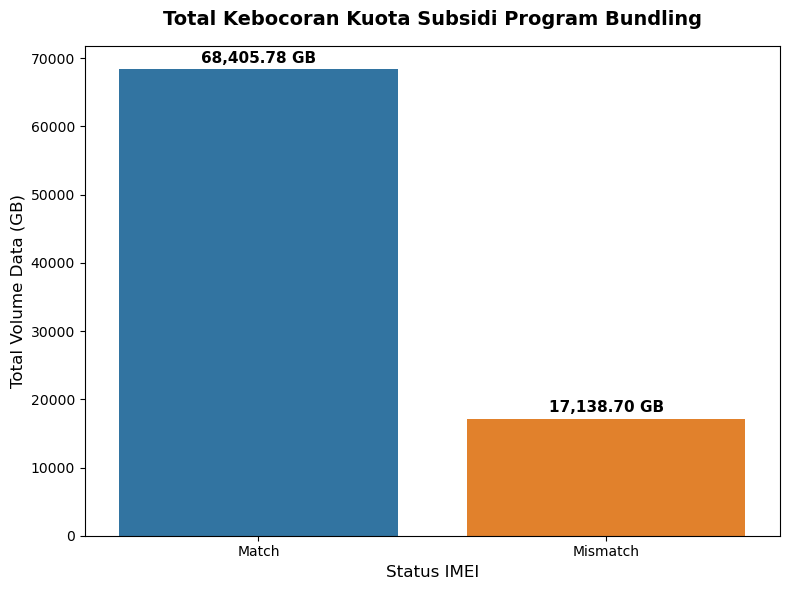

In [23]:
#visualisasi total kebocoran kuota subsidi

plt.figure(figsize=(8, 6))
sns.barplot(
    data=summary_bundling, 
    x='imei_status', 
    y='total_payload_gb', 
    hue='imei_status'
)

plt.title('Total Kebocoran Kuota Subsidi Program Bundling', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status IMEI', fontsize=12)
plt.ylabel('Total Volume Data (GB)', fontsize=12)

#menambahkan label angka di atas bar
for p in plt.gca().patches:
    plt.gca().annotate(
        f"{p.get_height():,.2f} GB", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 8), 
        textcoords='offset points', 
        fontsize=11, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

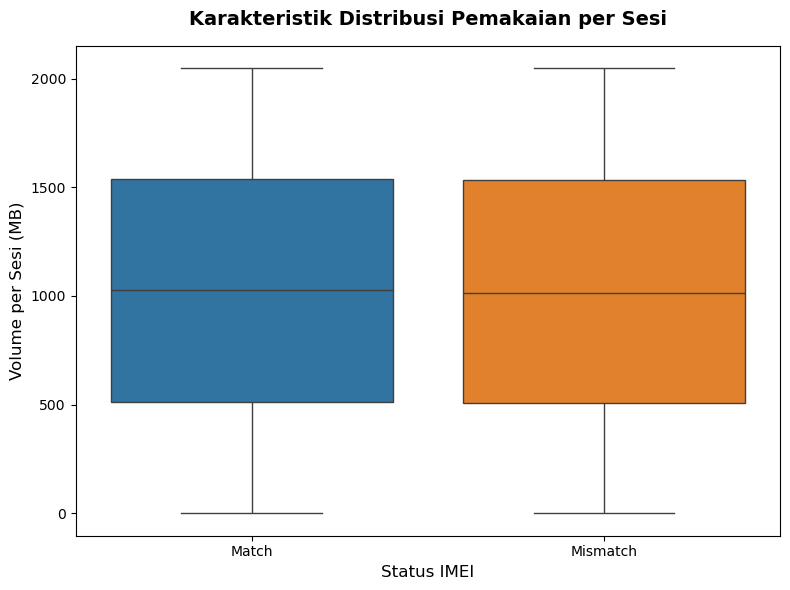

In [24]:

# visualisasi distribusi pemakaian per sesi
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_bundling, 
    x='imei_status', 
    y='payload_mb', 
    hue='imei_status'
)

plt.title('Karakteristik Distribusi Pemakaian per Sesi', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status IMEI', fontsize=12)
plt.ylabel('Volume per Sesi (MB)', fontsize=12)

plt.tight_layout()
plt.show()

> ini membuktikan bahwa pelaku fraud device bundling bukan tipe pengguna serakah (tethering abuse massal), melainkan kartu SIM premium tersebut sengaja dicopot dan diecer/dijual kembali ke pengguna prabayar reguler dengan pola pemakaian handphone normal (tetap berkisar di angka ~1 GB per sesi). Anggaran subsidi tetap bocor secara finansial karena target mengakuisisi segmen high-value smartphone users gagal

**Recommend:** Manajemen tidak bisa mendeteksi fraud ini hanya dengan memfilter batasan kuota (karena pemakaiannya normal). Salah satu solusi yang dapat diterapkan adalah implementasi **IMEI Locking** secara real-time pada Core Network (HLR/PCRF). Jika sistem mendeteksi `used_imei` $\neq$ `registered_imei`, paket data bundling premium harus otomatis dinonaktifkan atau diblokir seketika.

### **4.2 Korelasi Fenomena "Bakar Perdana" dengan Risiko Regulasi NIK/KK**

In [25]:
#crosstab frekuensi nilai absolut
cross_nik_abs = pd.crosstab(df_analisis['package_name'], df_analisis['nik_kk_status'])

#crosstab persentase
cross_nik_pct = pd.crosstab(df_analisis['package_name'], df_analisis['nik_kk_status'], normalize='index') * 100

print("=== FREKUENSI ABSOLUT ===")
print(cross_nik_abs)

print("\n=== PROPORSI PERSENTASE (%) ===")
print(cross_nik_pct.round(2))

=== FREKUENSI ABSOLUT ===
nik_kk_status           Missing/Unregistered  Valid
package_name                                       
Combo Sakti 15GB                        4259  24300
Combo Sakti 25GB                        4204  24566
Halo Bundling Samsung                   4228  24335
Halo Bundling iPhone                    4180  24173
Internet OMG! 100GB                     4267  24212
Internet OMG! 50GB                      4207  24293
Kuota Ketengan TikTok                   4054  24030
Kuota Ketengan YouTube                  4270  24194
Promo Perdana 15GB                      4224  24644
Promo Perdana 30GB                      4222  24291

=== PROPORSI PERSENTASE (%) ===
nik_kk_status           Missing/Unregistered  Valid
package_name                                       
Combo Sakti 15GB                       14.91  85.09
Combo Sakti 25GB                       14.61  85.39
Halo Bundling Samsung                  14.80  85.20
Halo Bundling iPhone                   14.74  85.26
Inter

> Jika kita menduga di awal bahwa status NIK/KK bolong (Missing/Unregistered) hanya menumpuk pada paket murah seperti Promo Perdana (gejala konter nakal meregistrasi massal secara ilegal untuk "Bakar Perdana"), data riil ternyata berkata lain.

Proporsi data yang Missing/Unregistered ternyata terdistribusi sangat merata di kisaran ~14.4% hingga 15.0% di seluruh produk, termasuk pada paket premium sekelas Halo Bundling iPhone (14.74%) dan Internet OMG! 100GB (14.98%). Dari hasil diatas, sebenarnya kita telah dapat jawaban bahwa hilangnya data NIK/KK bukan disebabkan oleh aktivitas kecurangan "Bakar Perdana". Namun, kita bisa membuktikan lagi secara matematis dengan uji Chi-Square.

Uji Chi-Square: Apakah status Missing NIK/KK itu ada hubungannya (dependen) dengan jenis paket tertentu, atau tidak berhubungan sama sekali (independen)?
- $H_0$ (Hipotesis Nol): Status registrasi NIK/KK independen (tidak berhubungan) dengan jenis paket data. (Artinya, bolongnya data NIK/KK murni karena error acak dari sistem internal).
- $H_1$ (Hipotesis Alternatif): Status registrasi NIK/KK dependen (berhubungan/terikat) dengan jenis paket data. (Artinya, ada paket tertentu yang sengaja diincar untuk dieksploitasi tanpa NIK/KK).

In [26]:

chi2, p_val, dof, expected = stats.chi2_contingency(cross_nik_abs)

print(f"Chi-Square Statistic : {chi2}")
print(f"P-Value              : {p_val}")

if p_value < 0.05:
    print("Kesimpulan           : Tolak H0! Terdapat hubungan antara status registrasi NIK/KK dengan jenis paket data")
else:
    print("Kesimpulan           : Gagal Tolak H0. Tidak ada hubungan")

Chi-Square Statistic : 6.277555482541816
P-Value              : 0.7118499989178969
Kesimpulan           : Gagal Tolak H0. Tidak ada hubungan


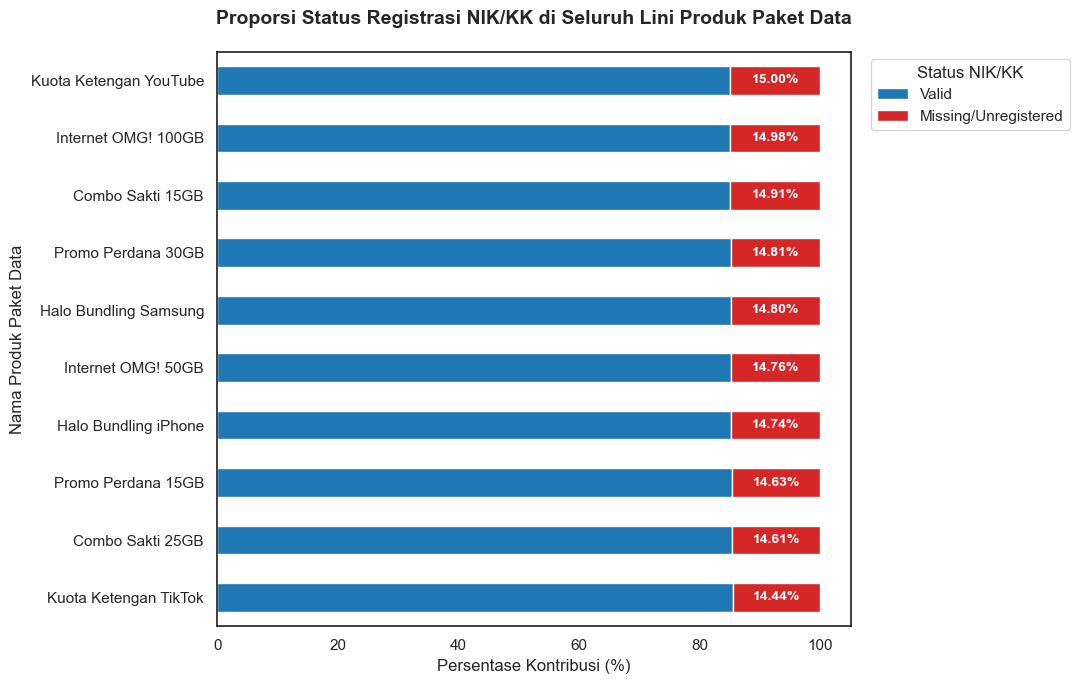

In [27]:
# visualisasi
df_vis_nik = cross_nik_pct.loc[:, ['Valid', 'Missing/Unregistered']].sort_values(by='Missing/Unregistered')

sns.set_theme(style="white")
ax = df_vis_nik.plot(
    kind='barh', 
    stacked=True, 
    figsize=(11, 7), 
    color=['#1f77b4', '#d62728'] #biru untuk valid, merah untuk missing
)

plt.title('Proporsi Status Registrasi NIK/KK di Seluruh Lini Produk Paket Data', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Persentase Kontribusi (%)', fontsize=12)
plt.ylabel('Nama Produk Paket Data', fontsize=12)
plt.legend(title='Status NIK/KK', bbox_to_anchor=(1.02, 1), loc='upper left')

#Menambahkan label
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_x(), p.get_y() 
    #hanya beri label jika itu adalah batang 'Missing/Unregistered' (dimulai setelah batang Valid)
    if x > 0 and width > 0:
        ax.annotate(f"{width:.2f}%", 
                    (x + width/2, y + height/2), 
                    ha='center', va='center', 
                    color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Hasil ini membuktikan bahwa hilangnya data NIK/KK bukan disebabkan oleh aktivitas kecurangan eksternal (sindikat konter nakal). Jika ini ulah sindikat, angka Missing akan melonjak extreme hanya di paket Promo Perdana dan bernilai mendekati 0% di paket premium. Karena polanya seragam di semua paket, ini adalah bukti konkrit adanya kegagalan sistemik internal (Internal System Bug) pada gate/interface integrasi database antara Telkomsel dengan Dukcapil/Kominfo saat proses aktivasi kartu terjadi di seluruh lini produk.

### 4.3 Variasi Konsumsi Data Antar Jenis Paket

Telkomsel menawarkan beberapa jenis paket data ke segmen pengguna yang berbeda, mulai dari paket Promo Perdana hingga paket premium seperti Halo Bundling. Asumsinya, pola konsumsi data per sesi pada paket premium akan lebih besar dibandingkan paket lain, sehingga berkontribusi signifikan terhadap ARPU. Untuk memvalidasi asumsi tersebut, akan dilakukan uji hipotesis statistik untuk mengetahui apakah terdapat perbedaan rata-rata konsumsi data per sesi antar jenis paket data.

In [ ]:
summary_paket = df_analisis.groupby('package_name').agg(
    total_sesi=('session_id', 'count'),
    total_payload_gb=('payload_mb', lambda x: x.sum() / 1024)
).reset_index()

print(summary_paket)

In [ ]:
rata_rata_paket = df_analisis.groupby('package_name')['payload_mb'].mean().reset_index()
rata_rata_paket.columns = ['package_name', 'avg_payload_mb']

print(rata_rata_paket.sort_values('avg_payload_mb', ascending=False))

Uji Hipotesis Statistik (One-Way ANOVA) untuk melihat apakah rata-rata konsumsi data per sesi (payload_mb) berbeda secara signifikan antar jenis paket data.

Hipotesis Uji:
- $H_0$: Tidak terdapat perbedaan rata-rata konsumsi data per sesi antar jenis paket data.
- $H_1$: Terdapat setidaknya 1 perbedaan rata-rata konsumsi data per sesi antar jenis paket.

In [ ]:
#uji ANOVA
from scipy.stats import f_oneway

groups = [grp['payload_mb'].values for name, grp in df_analisis.groupby('package_name')]
f_stat, p_value_anova = stats.f_oneway(*groups)

print(f"F-Statistic : {f_stat}")
print(f"P-Value     : {p_value_anova}")

if p_value < 0.05:
    print("Kesimpulan  : Tolak H0! Terdapat setidaknya 1 perbedaan rata-rata konsumsi data per sesi antar jenis paket")
    print("              Pola konsumsi data pelanggan berbeda antar jenis paket")
else:
    print("Kesimpulan  : Gagal Tolak H0. Tidak ada perbedaan signifikan")

In [ ]:
# visualisasi distribusi konsumsi data per sesi, antar jenis paket
plt.figure(figsize=(12, 7))

order_paket = df_analisis.groupby('package_name')['payload_mb'].mean().sort_values(ascending=False).index

sns.boxplot(
    data=df_analisis,
    x='package_name',
    y='payload_mb',
    order=order_paket,
    hue='package_name'
)

plt.title('Distribusi Konsumsi Data per Sesi Antar Jenis Paket', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jenis Paket Data', fontsize=12)
plt.ylabel('Volume per Sesi (MB)', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# visualisasi rata-rata konsumsi data per sesi, antar jenis paket
rata_rata_sort = rata_rata_paket.sort_values('avg_payload_mb', ascending=True)  # ascending 

sns.set_theme(style="white")
ax = rata_rata_sort.plot(
    kind='barh',
    x='package_name',
    y='avg_payload_mb',
    figsize=(11, 7),
    color='#1f77b4',  
    legend=False
)

plt.title('Rata-rata Konsumsi Data per Sesi di Seluruh Lini Produk Paket Data', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Rata-rata Volume per Sesi (MB)', fontsize=12)
plt.ylabel('Nama Produk Paket Data', fontsize=12)

# label angka di ujung tiap bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:,.1f} MB",
        (width, p.get_y() + p.get_height() / 2),
        ha='left', va='center', fontsize=10, xytext=(5, 0),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

**Rekomendasi** :Karena rendahnya ARPU bukan disebabkan oleh rendahnya intensitas pemakaian data, melainkan oleh pemilihan paket harga termurah oleh pelanggan yang pola konsumsinya setara paket premium, maka perlu dipertimbangkan strategi tiering ulang pada Paket Promo Perdana, seperti pembatasan kuota harian atau pembatasan pemakaian kuota promo pada jam tertentu. Diharapkan, pelanggan dengan pemakaian kuota besar akan terdorong untuk upgrade ke paket reguler atau premium.

#### 4.2.2 Visualisasi Tambahan

In [ ]:
import pandas as pd

sub = pd.read_csv('clean_subscribers.csv', 
                  parse_dates=['activation_date'])
pkg = pd.read_csv('clean_package.csv')
usage = pd.read_csv('clean_data_usage.csv', 
                    parse_dates=['session_time'])

print(f"Subscribers : {sub.shape}")
print(f"Packages    : {pkg.shape}")
print(f"Usage       : {usage.shape}")

In [ ]:
# Hitung jumlah pelanggan per kategori status NIK/KK
registrasi_NIK = sub.groupby('nik_kk_status').size()

# Buat pie chart
plt.figure(figsize=(6, 6))
plt.pie(registrasi_NIK, labels=registrasi_NIK.index, autopct='%1.1f%%', startangle=140)
plt.title("Proporsi status NIK/KK")
plt.axis('equal')  # untuk memastikan bentuk lingkaran
plt.tight_layout()
plt.show()

In [ ]:
# Bangun matrix pemetaan: baris = variasi mentah (BTS), kolom = kategori standar hasil cleaning
raw_counts = usage_raw['network_type'].value_counts()

mapping_matrix = pd.DataFrame(0, index=raw_counts.index, columns=['3G', '4G', '5G'])
for raw_value, count in raw_counts.items():
    standar = network_map.get(raw_value)
    if standar:
        mapping_matrix.loc[raw_value, standar] = count

# urutkan baris berdasarkan kategori tujuannya, biar terlihat rapi mengelompok per blok
mapping_matrix['target'] = mapping_matrix.idxmax(axis=1)
mapping_matrix = mapping_matrix.sort_values('target').drop(columns='target')

plt.figure(figsize=(7, 7))
sns.heatmap(
    mapping_matrix,
    annot=True,
    fmt=',d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Jumlah Sesi'}
)
plt.title('Pemetaan Standardisasi Network Type\n(10 Variasi Mentah BTS → 3 Kategori Standar)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Kategori Standar (Hasil Cleaning)', fontsize=11)
plt.ylabel('Variasi Penulisan Mentah (Raw Log BTS)', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Data Quality Scorecard: rekap jumlah temuan per jenis anomali sistem
scorecard = pd.DataFrame({
    'jenis_anomali': [
        'Sesi Sebelum\nAktivasi Kartu',
        'Payload Ekstrem\n(≥ 50.000 MB)',
        'Payload Negatif\n(< 0 MB)'
    ],
    'jumlah_temuan': [
        len(anomaly_time),
        len(outlier_extreme),
        len(outlier_extreme_min)
    ]
})

plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=scorecard,
    x='jenis_anomali',
    y='jumlah_temuan',
    hue='jenis_anomali',
    palette=['#d62728', '#f4a261', '#1f77b4'],
    legend=False
)

plt.title('Data Quality Scorecard: Temuan Anomali Sistem', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jenis Anomali', fontsize=12)
plt.ylabel('Jumlah Temuan (Baris)', fontsize=12)

# label angka di atas tiap bar
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,.0f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()

## **Section 5. Conclusion and Recommendation**

**5.1 Conclusion**

In [28]:
## conclusion

**5.2 Recommendation**